In [147]:
## Pandas [Python 완전정복 시리즈] 2편 : Pandas DataFrame 완전정복 ## 예제들 열심 정리
'''
#import sys ##{sys.executable} -m pip install pandas
'''
import pandas as pd
import numpy as np
np.random.seed(0)
arr = np.random.randint(10, size=(2, 2))  # 2*2 짜리 random array 생성
print(arr)
df1 = pd.DataFrame(arr, copy=False)   #copy=False : 원본데이타(arr)의 변형이 생기면 df1도 변함
df2 = pd.DataFrame(arr, copy=True)
print(df1)
print(df2)
arr[0,0] = 99
print(df1)
print(df2)

[[5 0]
 [3 3]]
   0  1
0  5  0
1  3  3
   0  1
0  5  0
1  3  3
    0  1
0  99  0
1   3  3
   0  1
0  5  0
1  3  3


In [148]:
data = {'A' : [1,2], 'B': [3,4], 'C':[5,6]}  # 'C':[5,6,7] 을 넣으면 에러남
df = pd.DataFrame(data=data)
print(df)

   A  B  C
0  1  3  5
1  2  4  6


In [149]:
#data = np.array([[1,2,], [4,5]])
data = [[1,2,], [3,4]]
df = pd.DataFrame(data=data, index=['row1','row2'], columns=['col1', 'col2'])
print(df)

      col1  col2
row1     1     2
row2     3     4


In [150]:
data = [[1,10,100],[2,20,200],[3,30,300]]
col = ['col1','col2','col3']
row = ['row1','row2','row3']
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
print(df.add(1))
print(df+1)
data2  = [[3],[4],[5]]
df2 = pd.DataFrame(data=data2,index=['row1','row2','row3'],columns=['col1'])
print(df2)
print(df.add(df2))                  #row1     4   NaN   NaN
print(df.add(df2,fill_value=0))     #row1     4  10.0  100.0  --> 대상 값이 없으면 0으로 더해줘


      col1  col2  col3
row1     1    10   100
row2     2    20   200
row3     3    30   300
      col1  col2  col3
row1     2    11   101
row2     3    21   201
row3     4    31   301
      col1  col2  col3
row1     2    11   101
row2     3    21   201
row3     4    31   301
      col1
row1     3
row2     4
row3     5
      col1  col2  col3
row1     4   NaN   NaN
row2     6   NaN   NaN
row3     8   NaN   NaN
      col1  col2   col3
row1     4  10.0  100.0
row2     6  20.0  200.0
row3     8  30.0  300.0


In [151]:
col = ['col1','col2']
row = ['row1','row2']
data1 = [[1,2],[3,4]]
data2 = [[5,6],[7,8]]
df1 = pd.DataFrame(data=data1)
df2 = pd.DataFrame(data=data2)
print(df1)
print(df2)
df3 = df1.dot(df2)
print(df3)      #1*5+2*7 / 1*6+2*8 / 3*5+4*7 / 3*6+4*8

   0  1
0  1  2
1  3  4
   0  1
0  5  6
1  7  8
    0   1
0  19  22
1  43  50


In [152]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = np.random.rand(3,3)*100
df = pd.DataFrame(data=data, index=row, columns=col)
print(df)
print(df.round(1))
print(df.round(-1))

           col1       col2       col3
row1  84.725174  62.356370  38.438171
row2  29.753461   5.671298  27.265629
row3  47.766512  81.216873  47.997717
      col1  col2  col3
row1  84.7  62.4  38.4
row2  29.8   5.7  27.3
row3  47.8  81.2  48.0
      col1  col2  col3
row1  80.0  60.0  40.0
row2  30.0  10.0  30.0
row3  50.0  80.0  50.0


In [153]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = [[1,2,3],[4,5,6],[7,np.nan,9]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
print(df.sum(axis=0))  #0은 컬럼
print(df.sum(axis=1))  #1은 행
print(df.sum(axis=0,skipna=False))
print(df.sum(axis=1,min_count=3))  # min_count : 계산에 필요한 최소갯수-부족하면 NaN출력

      col1  col2  col3
row1     1   2.0     3
row2     4   5.0     6
row3     7   NaN     9
col1    12.0
col2     7.0
col3    18.0
dtype: float64
row1     6.0
row2    15.0
row3    16.0
dtype: float64
col1    12.0
col2     NaN
col3    18.0
dtype: float64
row1     6.0
row2    15.0
row3     NaN
dtype: float64


In [154]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = [[1,2,3],[4,5,6],[7,np.nan,9]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
print(df.prod(axis=0))
print(df.prod(axis=1))
print(df.prod(axis=0, skipna=False))
print(df.prod(axis=1, min_count=3))

      col1  col2  col3
row1     1   2.0     3
row2     4   5.0     6
row3     7   NaN     9
col1     28.0
col2     10.0
col3    162.0
dtype: float64
row1      6.0
row2    120.0
row3     63.0
dtype: float64
col1     28.0
col2      NaN
col3    162.0
dtype: float64
row1      6.0
row2    120.0
row3      NaN
dtype: float64


In [155]:
## 절대값, 복소수
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = [[-1,2,-3.5],[4,-5.5, 3+4j],[7,np.nan,0]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
print(df.abs( ))

      col1  col2      col3
row1    -1   2.0 -3.5+0.0j
row2     4  -5.5  3.0+4.0j
row3     7   NaN  0.0+0.0j
      col1  col2  col3
row1     1   2.0   3.5
row2     4   5.5   5.0
row3     7   NaN   0.0


In [156]:
col = ['col1','col2','col3']
row = ['row1','row2','row3','row4']
data = [['A',1,2],['B',3,4],['C',5,6],['D',7,8]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
print(df.transpose())

     col1  col2  col3
row1    A     1     2
row2    B     3     4
row3    C     5     6
row4    D     7     8
     row1 row2 row3 row4
col1    A    B    C    D
col2    1    3    5    7
col3    2    4    6    8


In [157]:
data = [[5],[5],[pd.NA],[3],[-3.1],[5],[0.4],[6.7],[3]]
row = ['A★','B★','C','D☆','E','F★','G','H','I☆']
df = pd.DataFrame(data=data, index=row, columns=['Value'])
print(df)
df['average']=df['Value'].rank(method='average')
df['min']=df['Value'].rank(method='min')
df['max']=df['Value'].rank(method='max')
df['first']=df['Value'].rank(method='first')
df['dense']=df['Value'].rank(method='dense')
df['keep']=df['Value'].rank(na_option='keep')
df['top']=df['Value'].rank(na_option='top')
df['bottom']=df['Value'].rank(na_option='bottom')
df['pct']=df['Value'].rank(pct=True)
print(df)

   Value
A★     5
B★     5
C   <NA>
D☆     3
E   -3.1
F★     5
G    0.4
H    6.7
I☆     3
   Value  average  min  max  first  dense  keep  top  bottom     pct
A★     5      6.0  5.0  7.0    5.0    4.0   6.0  7.0     6.0  0.7500
B★     5      6.0  5.0  7.0    6.0    4.0   6.0  7.0     6.0  0.7500
C   <NA>      NaN  NaN  NaN    NaN    NaN   NaN  1.0     9.0     NaN
D☆     3      3.5  3.0  4.0    3.0    3.0   3.5  4.5     3.5  0.4375
E   -3.1      1.0  1.0  1.0    1.0    1.0   1.0  2.0     1.0  0.1250
F★     5      6.0  5.0  7.0    7.0    4.0   6.0  7.0     6.0  0.7500
G    0.4      2.0  2.0  2.0    2.0    2.0   2.0  3.0     2.0  0.2500
H    6.7      8.0  8.0  8.0    8.0    5.0   8.0  9.0     8.0  1.0000
I☆     3      3.5  3.0  4.0    4.0    3.0   3.5  4.5     3.5  0.4375


In [158]:
idx=['A','A','B','B','B','C','C','C','D','D','D','D','E','E','E']
col=['col1','col2','col3']
data = np.random.randint(0,9,(15,3))
df = pd.DataFrame(data=data, index=idx, columns=col).reset_index()
print(df)
def top (df,n=2,col='col1'):
    return df.sort_values(by=col)[-n:] #상위 n개 열을 반환하는 함수 top 생성
#print(df.groupby('index').apply(top))
print(df.groupby('index',group_keys=False).apply(top))
df_cat = pd.Categorical(df['index'], categories=['A','B','C','D','E','F']) # df의 index열에 대해서 A,B,C,D,E,F 로 Categorical을 하여 df_cat 생성
print(df_cat)
#print(df['col1'].groupby(df_cat).count()) # # index열에는 없지만, F까지 category 되었음. observed=False(기본값)인 경우 카테고리 전체가 표시됨.
print(df['col1'].groupby(df_cat,observed=True).count())
print(df.groupby(['index'],as_index=False).sum())

   index  col1  col2  col3
0      A     1     5     8
1      A     4     3     0
2      B     3     5     0
3      B     2     3     8
4      B     1     3     3
5      C     3     7     0
6      C     1     0     4
7      C     7     3     2
8      D     7     2     0
9      D     0     4     5
10     D     5     6     8
11     D     4     1     4
12     E     8     1     1
13     E     7     3     6
14     E     7     2     0
    col1  col2  col3
0      1     5     8
1      4     3     0
3      2     3     8
2      3     5     0
5      3     7     0
7      7     3     2
10     5     6     8
8      7     2     0
14     7     2     0
12     8     1     1
['A', 'A', 'B', 'B', 'B', ..., 'D', 'D', 'E', 'E', 'E']
Length: 15
Categories (6, str): ['A', 'B', 'C', 'D', 'E', 'F']
A    2
B    3
C    3
D    4
E    3
Name: col1, dtype: int64
  index  col1  col2  col3
0     A     5     8     8
1     B     6    11    11
2     C    11    10     6
3     D    16    13    17
4     E    22     6     7


In [159]:
print(df.groupby('index')) # index 컬럼에 대해서 groupby 수행
print(df.groupby('index').agg(['sum', 'mean', 'count']))

      col1                 col2                 col3                
       sum      mean count  sum      mean count  sum      mean count
index                                                               
A        5  2.500000     2    8  4.000000     2    8  4.000000     2
B        6  2.000000     3   11  3.666667     3   11  3.666667     3
C       11  3.666667     3   10  3.333333     3    6  2.000000     3
D       16  4.000000     4   13  3.250000     4   17  4.250000     4
E       22  7.333333     3    6  2.000000     3    7  2.333333     3


In [160]:
idx=['A','A','B','B','B','C','C','C','D','D','D','D','E','E','E']
col=['col1','col2','col3']
data = np.random.randint(0,9,(15,3))
df = pd.DataFrame(data=data, index=idx, columns=col).reset_index()
print(df)
def top (df,n=2,col='col1'):
    return df.sort_values(by=col)[-n:] #상위 n개 열을 반환하는 함수 top 생성
#print(df.groupby('index').apply(top))   # 인덱스와 index열이 중복
#print(df.groupby('index',group_keys=False).apply(top)) # 인덱스와의 중복이 제거
df_cat = pd.Categorical(df['index'], categories=['A','B','C','D','E','F']) # df의 index열에 대해서 A,B,C,D,E,F 로 Categorical을 하여 df_cat 생성
print(df_cat)
#print(df['col1'].groupby(df_cat).count())
#print(df['col1'].groupby(df_cat,observed=True).count()) #observed=True로 할경우 관찰되지 않는값 (카테고리에만 존재하는값)은 표시되지 않음.
print(df.groupby(['index'],as_index=False).sum())

   index  col1  col2  col3
0      A     3     5     4
1      A     4     6     4
2      B     4     3     4
3      B     4     8     4
4      B     3     7     5
5      C     5     0     1
6      C     5     3     0
7      C     5     0     1
8      D     2     4     2
9      D     0     3     2
10     D     0     7     5
11     D     0     2     7
12     E     2     2     3
13     E     3     2     3
14     E     4     1     2
['A', 'A', 'B', 'B', 'B', ..., 'D', 'D', 'E', 'E', 'E']
Length: 15
Categories (6, str): ['A', 'B', 'C', 'D', 'E', 'F']
  index  col1  col2  col3
0     A     7    11     8
1     B    11    18    13
2     C    15     3     2
3     D     2    16    16
4     E     9     5     8


In [161]:
idx=['A','A','B','B','B','C','C','C','D','D','D','D','E','E','E']
col=['col1','col2','col3']
data = np.random.randint(0,9,(15,3))
df = pd.DataFrame(data=data, index=idx, columns=col).reset_index()
df.loc[6,'index'] = np.nan
print(df)
print(df.groupby('index').sum()) #NaN은 계산에서 제외
print(df.groupby('index',dropna=False).sum()) # NaN이 표시됩니다.

   index  col1  col2  col3
0      A     1     4     6
1      A     8     2     3
2      B     0     0     6
3      B     0     6     3
4      B     3     8     8
5      C     8     2     3
6    NaN     2     0     8
7      C     8     3     8
8      D     2     8     4
9      D     3     0     4
10     D     3     6     8
11     D     0     8     5
12     E     0     6     5
13     E     3     1     8
14     E     0     4     6
       col1  col2  col3
index                  
A         9     6     9
B         3    14    17
C        16     5    11
D         8    22    21
E         3    11    19
       col1  col2  col3
index                  
A         9     6     9
B         3    14    17
C        16     5    11
D         8    22    21
E         3    11    19
NaN       2     0     8


In [162]:
idx = [['idx1','idx1','idx2','idx2','idx2'],['row1','row2','row1','row2','row3']]
col = ['col1','col2','col2']
data = np.random.randint(0,9,(5,3))
df = pd.DataFrame(data=data, index = idx, columns = col).rename_axis(index=['lv0','lv1'])
print(df)
print(df.groupby(level=1).sum())
print(df.groupby(['lv1','lv0']).sum())

           col1  col2  col2
lv0  lv1                   
idx1 row1     5     7     8
     row2     8     2     8
idx2 row1     6     6     1
     row2     6     8     8
     row3     3     2     3
      col1  col2  col2
lv1                   
row1    11    13     9
row2    14    10    16
row3     3     2     3
           col1  col2  col2
lv1  lv0                   
row1 idx1     5     7     8
     idx2     6     6     1
row2 idx1     8     2     8
     idx2     6     8     8
row3 idx2     3     2     3


 지수가중함수 (ewm)
 DataFrame.ewm(com=None, span=None, halflife=None, alpha=None, min_periods=0, adjust=True, ignore_na=False, axis=0, times=None, method='single')
 => ewm 은 지수가중함수 입니다. 지수가중함수는 오래된 데이터에 지수감쇠를 적용하여 최근 데이터가 더 큰 영향을 끼지도록 가중치를 주는 함수입니다.
보통 추가 메서드로 mean() 을 사용해서 지수가중평균으로 사용합니다.

기본 사용법
※ 자세한 내용은 아래 예시를 참고 바랍니다.
df.ewm(com=None, span=None, halflife=None, alpha=None, min_periods=0, adjust=True, ignore_na=False, axis=0, times=None, method='single')

기본적으로 가중치를 결정하는 요소는 alpha 로 표기되는 평활계수(감쇠계수) 입니다. com / span / halflife를 통해 자동 계산하도록 하거나, alpha를 통해 직접 설정할 수 있습니다.


com : 질량중심 값으로 평활계수를 계산합니다. [ a = 1(1+com) ]
span : 계산 기간으로 평활계수를 계산합니다. [ a = 2/(span+1) ]
halflife : 반감기를 이용하여 평활계수를 계산합니다. [ a= e^(-ln(2) / halflife) ]
alpha : 평활계수를 직접 입력합니다. [ 0 < a ≤ 1 ]
min_periods : 계산을위한 최소 기간입니다.
adjust : 상대적 가중치의 불균형을 해소하기위해 조정계수로 나눌지의 여부입니다. 대체로 값이 많을수록 adjust를 하는것이 유리합니다.
ignore_na : 가중치를 계산할때 누락값을 무시할지 여부 입니다.

[x0, None, x1] 일때, 인 경우 ignore_na = False 이면 절대위치를 기반으로 하며,
x0와 x2의 가중치는 adjust = [ True인경우 (1-a)^2와 1 / False인 경우 (1-a)^2와 a ] 입니다.
[x0, None, x1] 일때, 인 경우 ignore_na = False 이면 절대위치를 기반으로 하며,
x0와 x2의 가중치는 adjust = [ True인경우 (1-a)와 1 / False인 경우 (1-a)와 a ] 입니다.


axis : 계산을 수행할 축 입니다.
times : 관찰에 해당하는 시간입니다. 단조증가 형태의 datetime64[ns] 형태여야합니다.
method : {single / table} 한 줄씩 계산할지(기본값) 아니면 numba engine을 사용해서 table단위로 계산할지 정할 수 있습니다.
numba 라이브러리를 import 해야하며 사용시 ewm(method='table').mean(engine='numba') 처럼 추가 메서드에 engine 설정을 해줘야합니다.


In [ ]:
import sys
!{sys.executable} -m pip install numba
import numba
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


    index   val
0       0   1.0
1       1   4.0
2       2   2.0
3       3   3.0
4       4   2.0
5       5   5.0
6       6  13.0
7       7  10.0
8       8  12.0
9       9  14.0
10     10   NaN
11     11  16.0
12     12  12.0
13     13  20.0
14     14  22.0


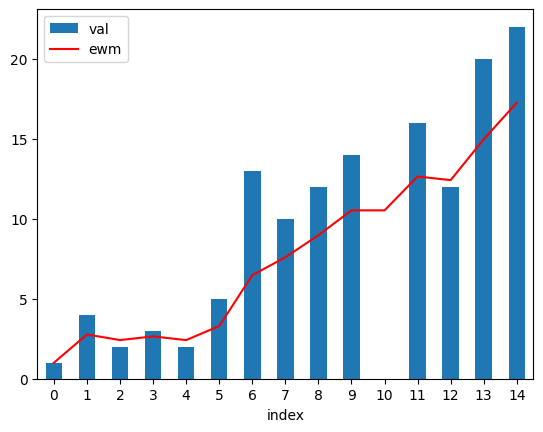

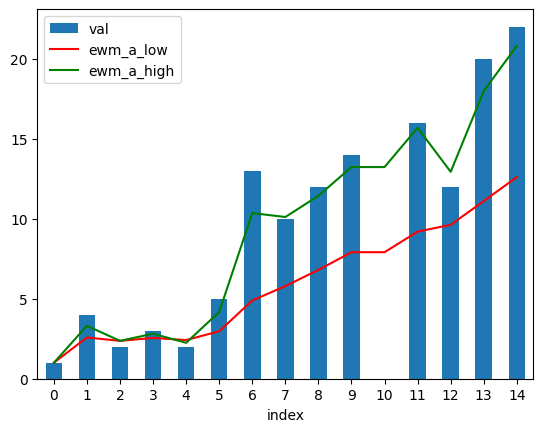

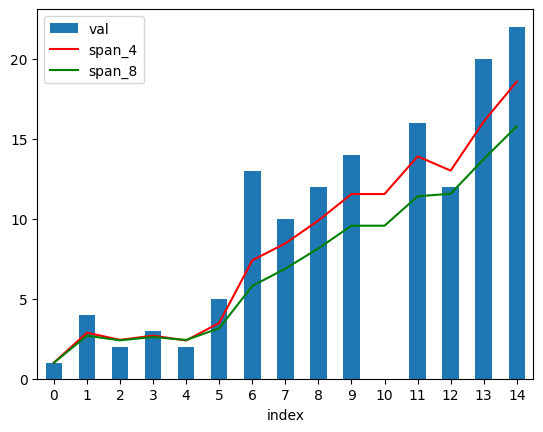

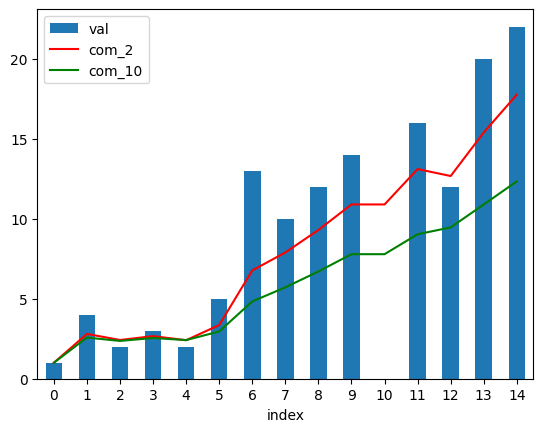

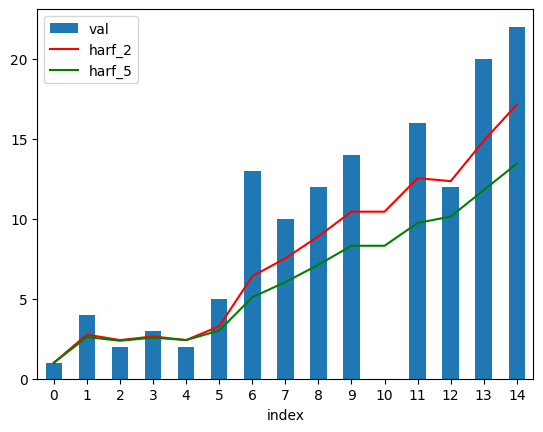

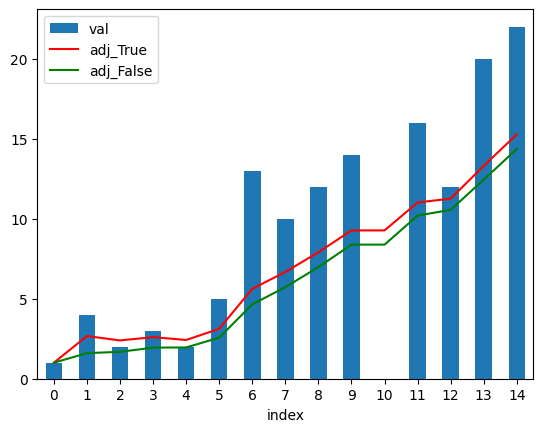

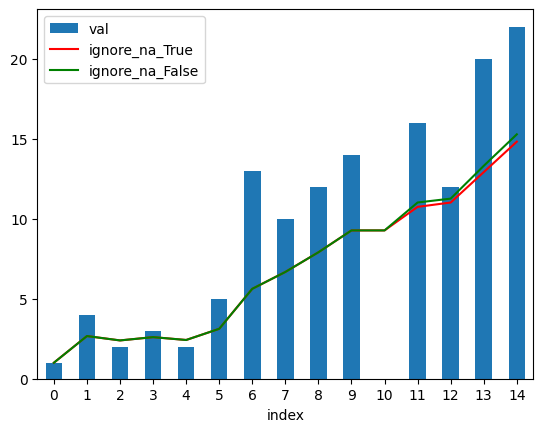

          val
0    1.000000
1    2.666667
2    2.393443
3    2.598916
4    2.420752
5    3.119872
6    5.620269
7    6.672800
8    7.903410
9    9.269400
10   9.269400
11  11.014705
12  11.255896
13  13.304608
14  15.274352


In [127]:
import matplotlib.pyplot as plt

data = {'val':[1,4,2,3,2,5,13,10,12,14,np.nan,16,12,20,22]}
df = pd.DataFrame(data).reset_index()
print(df)
df2 = df.assign(ewm=df['val'].ewm(alpha=0.3).mean()) # val열에 ewm 메서드적용 후 df에 추가
ax = df.plot(kind='bar',x='index',y='val') # ax에 df의 bar chart 생성
ax2= df2.plot(kind='line',x='index', y='ewm', color='red', ax=ax) # ax2에 df2의 line chart 생성후 ax에 추가
plt.show() # 그래프 출력
#alpha는 평활계수로써, 자동 계산이 가능하지만, alpha 인수를 직접 입력하여 설정이 가능합니다.
#alpha가 클수록 더 큰 변화에 민감하며, alpha가 작을수록 평활한 그래프가 생성됩니다.
#alpha가 0.1인 적색선보다. alpha가 0.7인 녹색선이 급격한 변화에 더 민감한 것을 볼 수 있습니다.
df2 = df.assign(ewm_a_low=df['val'].ewm(alpha=0.1).mean()) #alpha=0.1로 df2 생성
df3 = df.assign(ewm_a_high=df['val'].ewm(alpha=0.7).mean()) #alpha=0.7로 df3 생성
ax = df.plot(kind='bar',x='index',y='val') 
ax2= df2.plot(kind='line',x='index', y='ewm_a_low', color='red', ax=ax) # alpha=0.1 은 적색
ax3= df3.plot(kind='line',x='index', y='ewm_a_high', color='green', ax=ax) # alpha=0.7 은 녹색
plt.show()
#span은 기간을 지정하여 평활계수를 계산하는 인수입니다. 계산식은 a = 2/(span+1)으로 계산 기간이 길어질수록 a가 작아집니다.
#span이 긴 녹색이 span이 짧은 적색선보다 덜 민감하게 반응하는 것을 확인 할 수 있습니다.
#span이 길면 그만큼 과거의 데이터의 영향이 커지기 때문입니다.
df2 = df.assign(span_4=df['val'].ewm(span=4).mean())
df3 = df.assign(span_8=df['val'].ewm(span=8).mean())
ax = df.plot(kind='bar',x='index',y='val')
ax2= df2.plot(kind='line',x='index', y='span_4', color='red', ax=ax)
ax3= df3.plot(kind='line',x='index', y='span_8', color='green', ax=ax)
plt.show()
#com 은 질량중심 감쇠법으로 평활계수를 계산하는 인수입니다. 계산식은 a=1/(1+com)으로 com이 커질수록 a가 작아집니다.
#com이 큰 녹색이 com이 작은 적색보다 덜 민감하게 반응하는 것을 확인할 수 있습니다.
#com이 클 수록 과거의 데이터의 가중치가 커지기 때문입니다.
df2 = df.assign(com_2=df['val'].ewm(com=2).mean())
df3 = df.assign(com_10=df['val'].ewm(com=10).mean())
ax = df.plot(kind='bar',x='index',y='val')
ax2= df2.plot(kind='line',x='index', y='com_2', color='red', ax=ax)
ax3= df3.plot(kind='line',x='index', y='com_10', color='green', ax=ax)
plt.show()
#halflife인수는 반감기를 이용하여 평활계수를 계산하는 인수입니다. 계산식은 a=1-e^(-ln(2)/halflife) 으로 halflife가 길어질수록 a가 작아집니다.
#halflife 반감기가 길수록(녹색) 더욱 둔감한 그래프가 그려지는것을 확인할 수 있습니다.
df2 = df.assign(harf_2=df['val'].ewm(halflife=2).mean())
df3 = df.assign(harf_5=df['val'].ewm(halflife=5).mean())
ax = df.plot(kind='bar',x='index',y='val')
ax2= df2.plot(kind='line',x='index', y='harf_2', color='red', ax=ax)
ax3= df3.plot(kind='line',x='index', y='harf_5', color='green', ax=ax)
plt.show()
#adjust인수는 상대적 가중치의 불균형을 해소하기위해 조정계수로 나눌지의 여부입니다. 대체로 값이 많을수록 adjust를 하는것이 유리합니다.
df2 = df.assign(adj_True=df['val'].ewm(alpha=0.2,adjust=True).mean())
df3 = df.assign(adj_False=df['val'].ewm(alpha=0.2,adjust=False).mean())
ax = df.plot(kind='bar',x='index',y='val')
ax2= df2.plot(kind='line',x='index', y='adj_True', color='red', ax=ax)
ax3= df3.plot(kind='line',x='index', y='adj_False', color='green', ax=ax)
plt.show()
# ignore_na인수는 결측치가 존재할 경우 가중치를 어떻게 설정할지 정하는 인수 입니다.
#[x0, None, x1] 일때, 인 경우 ignore_na = False 이면 절대위치를 기반으로 하며,
#x0와 x2의 가중치는 adjust = [ True인경우 (1-a)^2와 1 / False인 경우 (1-a)^2와 a ] 입니다.
#[x0, None, x1] 일때, 인 경우 ignore_na = False 이면 절대위치를 기반으로 하며,
#x0와 x2의 가중치는 adjust = [ True인경우 (1-a)와 1 / False인 경우 (1-a)와 a ] 입니다.

#결측치가 있는 10번 data부터 ignore_na의 여부에 따라 그래프가 달라지는것을 볼 수 있습니다.
df2 = df.assign(ignore_na_True=df['val'].ewm(alpha=0.2,ignore_na=True).mean())
df3 = df.assign(ignore_na_False=df['val'].ewm(alpha=0.2,ignore_na=False).mean())
ax = df.plot(kind='bar',x='index',y='val')
ax2= df2.plot(kind='line',x='index', y='ignore_na_True', color='red', ax=ax)
ax3= df3.plot(kind='line',x='index', y='ignore_na_False', color='green', ax=ax)
plt.show()
'''
method 인수의 사용
method인수는 single인 경우 한줄씩, table인 경우 전체 테이블을 한번에 계산합니다. 데이터가 많을수록 method='table'이 속도에서 유리합니다.
사용시 추가 메서드에서 engine='numba' 형태로 설정을 해주어야 합니다.
'''
import numba
print(df[['val']].ewm(alpha=0.2, method='table').mean(engine='numba'))  # df['val'].ewm(alpha=0.2, method='table').mean(engine='numba')  --> sereise형태는 에러남 따라서 df[['val']] dataframe으로 변경함

In [128]:
#import sys
!{sys.executable} -m pip install numba


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [129]:
import numba
import pandas as pd
import numpy as np


축 기준 (apply)
DataFrame.apply(func, axis=0, raw=False, result_type=None, args=(), **kwargs)
* apply 메서드는 DataFrame에 함수를 적용하여 반환하는 메서드 입니다.
* 최종반환 유형은 적용된 함수에 따라 정해지지만 result_type을 지정하여 변경이 가능합니다.

df.apply(func, axis=0, raw=False, result_type=None, args=(), kwargs)
function : 각 행이나 열에 적용할 함수 입니다.
axis : {0 : Index / 1 : columns} 함수를 적용할 축 입니다.
row : {True : ndarray / False : Series} 함수에 전달할 축의 형식입니다.
True면 ndarray형태로 전달하고 False면 Series형태로 전달합니다. 기본적으로 Series입니다.
result_type : {expand / reduce / broadcast} 반환값의 형태를 결정합니다. expand이면 배열 형태를
기준으로 열을 확장합니다.(기본 인덱스로), reduce인 경우는 그대로 Serise형태로 반환합니다.
broadcase인 경우 기존 열 형식대로 확장하여 반환합니다.(열의 수가 같아야합니다.)

In [130]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = [[1,2,3],[4,5,6],[7,8,9]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9


In [131]:
print(df.apply(np.sqrt))
print(df.apply(np.prod,axis=0))
print(df.apply(np.prod,axis=1))
print(df.apply(lambda x : [1,2,3]))
print(df.apply(lambda x : [1,2,3], axis=1,result_type='expand'))
print(df.apply(lambda x : [1,2,3], axis=1,result_type='reduce'))
print(df.apply(lambda x : [1,2,3], axis=1,result_type='broadcast'))

          col1      col2      col3
row1  1.000000  1.414214  1.732051
row2  2.000000  2.236068  2.449490
row3  2.645751  2.828427  3.000000
col1     28
col2     80
col3    162
dtype: int64
row1      6
row2    120
row3    504
dtype: int64
      col1  col2  col3
row1     1     1     1
row2     2     2     2
row3     3     3     3
      0  1  2
row1  1  2  3
row2  1  2  3
row3  1  2  3
row1    [1, 2, 3]
row2    [1, 2, 3]
row3    [1, 2, 3]
dtype: object
      col1  col2  col3
row1     1     2     3
row2     1     2     3
row3     1     2     3


요소별 (applymap)
*DataFrame.applymap(func, na_action=None, **kwargs)
applymap 메서드는 객체의 각 요소에 함수를 적용하는 메서드입니다.
즉, apply메서드와는 다르게 DataFrame의 각 요소 하나하나에 함수를 적용하여 스칼라 값을 반환합니다.

df.apply(func, axis=0, raw=False, result_type=None, args=(), kwargs)
func : 단일 값을 반환하는 함수 입니다.
na_action : {None / 'ignore} NaN의 무시 여부입니다. 'ignore'이면 NaN을 함수로 전달하지 않습니다.

In [132]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
data = [[1,2,3],[4,5,6],[7,pd.NA,9]]
df = pd.DataFrame(data=data,index=row,columns=col)
print(df)
#print(df.applymap(lambda x : x**2))
print(df.map(lambda x : x**2,na_action='ignore'))

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7  <NA>     9
      col1  col2  col3
row1     1     4     9
row2    16    25    36
row3    49  <NA>    81


함수내 함수 연속적용 (pipe)
*DataFrame.pipe(func, args, kwargs)
pipe 메서드는 함수를 연속적으로 사용할 때 유용한 메서드입니다.
특히 함수가 인수를 사용할 때 pipe 메서드를 사용하면 보다 직관적으로 적용할 수 있습니다.

df.pipe(func, args, kwargs)
func : 함수입니다.
arg : 함수의 인수입니다.
kwargs : dict 형태의 함수의 인수입니다.

만약 함수 3개가 아래와 같이 있다고 해봅니다.
f1(data, arg1), f2(data, arg1, arg2), f3(data, arg3)
f1 > f2 > f3 순서로 포함되게 함수를 사용한다고 하면 아래와 같이 함수를 사용해야 합니다.
df=f1( f2( f3( data,arg3='c' ),arg2='b1',arg3='b2' ),arg1='a' )
이는 어떤 arg가 어떤함수인지 직관적으로 볼 수 없습니다. 이때, pipe함수를 사용할 수 있습니다.
df=data.pipe(f3, arg3='c').pipe(f2, arg2='b1', arg3='b2').pipe(f3, arg3='c')

In [133]:
org_data = pd.DataFrame({'info':['삼성전자/3/70000','SK하이닉스/2/100000']})
print(org_data)
def code_name(data):
    result=pd.DataFrame(columns=['name','count','price']) 
    df = pd.DataFrame(list(data['info'].str.split('/'))) # '/ ' 로 구분하여 문자열을 나누어 리스트에 넣음
    result['name'] = df[0] # 여기엔 첫번째 값인 이름이 입력
    result['count']= df[1] # 여기엔 두번째 값인 수량이 입력
    result['price']= df[2] # 여기엔 세번째 값인 가격이 입력
    result = result.astype({'count':int, 'price':int})# count와 price를 int로 바꿈(기존str)
    return result
print(code_name(org_data))

def value_cal(data,unit=''):
    result = pd.DataFrame(columns=['name','value']) 
    result['name'] =data['name'] # 이름은 기존거를 가져옴
    result['value']=data['count']*data['price'] # value는 count * price를 입력함
    result = result.astype({'value':str}) # value를 str로 변경(단위를 붙이기 위함)
    result['value']=result['value']+unit # 단위를 붙임
    return(result)

input=code_name(org_data)
print(value_cal(input,'원'))

#pipe 메서드를 사용하지 않는경우
#만약 pipe메서드를 사용하지 않는다면 아래와같이 함수를 사용해야 합니다.
print(value_cal(code_name(org_data),'원'))

#pipe 메서드를 사용하는 경우
#만약 pipe메서드를 사용하지 않는다면 아래와같이 함수를 사용해야 합니다.
print(org_data.pipe(code_name).pipe(value_cal,'원'))



              info
0     삼성전자/3/70000
1  SK하이닉스/2/100000
     name  count   price
0    삼성전자      3   70000
1  SK하이닉스      2  100000
     name    value
0    삼성전자  210000원
1  SK하이닉스  200000원
     name    value
0    삼성전자  210000원
1  SK하이닉스  200000원
     name    value
0    삼성전자  210000원
1  SK하이닉스  200000원


함수연속적용_축별 (aggregate, agg)
*DataFrame.aggregate(func=None, axis=0, args, kwargs)
*DataFrame.agg(func=None, axis=0, args, kwargs)

agg메서드는 apply와 비슷하게 함수를 적용하는 메서드이지만,
여러개의 함수를 동시에 적용할 수 있다는 장점이 있습니다.
그리고 __name__를통해 사용자정의 함수명을 따로 설정할경우 그 이름을 사용한다는 점을 활용하여
함수를 사용한 DataFrame을 보다 깔끔하게 정리하는데도 용이하게 쓸 수 있습니다.

df.agg(func=None, axis=0, args, kwargs)
func : 함수입니다.
axis :{0 : index(row) / 1 : columns} 축입니다 0은 행, 1은 열 입니다. arg : 함수의 인수 입니다..
kwargs : dict 형태의 함수의 인수입니다.

In [134]:
df = pd.DataFrame([[1,4,7],[2,5,8],[3,6,9]])
print(df)
ex1 = df.agg(np.prod)
print(ex1)
ex2 = df.agg('prod')
print(ex2)
ex12 = df.aggregate('prod', axis=1)
print(ex12)
ex3 = df.agg([lambda x : min(x) * max(x)])
print(ex3)
def func_sub(input):
    return max(input)-min(input)
ex4 = df.agg([func_sub,'sum'])
print(ex4)
def func_sub(input):
    return max(input)-min(input)
func_sub.__name__='내함수'
ex5 = df.agg([func_sub,'sum'])
print(ex5)
ex6 = df.agg(['min','max','sum','prod'])
print(ex6)
ex7 = df.agg({2:'sum',0:'max',1:'min'})  ## dict를 이용하는 경우 순서를 변경하는것도 가능합니다. --> 이것 잘 봐둬야 함..헷갈리게 만든 요지 있음
print("***dict***\n", ex7)
ex8 = df.agg({0:['sum','prod'],1:['max','min'],2:'mean'})
print(ex8)       

   0  1  2
0  1  4  7
1  2  5  8
2  3  6  9
0      6
1    120
2    504
dtype: int64
0      6
1    120
2    504
dtype: int64
0     28
1     80
2    162
dtype: int64
          0   1   2
<lambda>  3  24  63
          0   1   2
func_sub  2   2   2
sum       6  15  24
     0   1   2
내함수  2   2   2
sum  6  15  24
      0    1    2
min   1    4    7
max   3    6    9
sum   6   15   24
prod  6  120  504
***dict***
 2    24
0     3
1     4
dtype: int64
        0    1    2
sum   6.0  NaN  NaN
prod  6.0  NaN  NaN
max   NaN  6.0  NaN
min   NaN  4.0  NaN
mean  NaN  NaN  8.0


함수연속적용_요소별 (transform)
*DataFrame.transform(func, axis=0, args, kwargs)
transform메서드는 agg와 비슷하게 함수를 적용하는 메서드이지만,
단일 요소별로 함수를 동시에 적용할 수 있다는 장점이 있습니다. 마치 apply와 applymap의 차이와 비슷합니다.
df.transform(func, axis=0, args, kwargs)
func : 함수입니다.
axis :{0 : index(row) / 1 : columns} 축입니다 0은 행, 1은 열 입니다.
arg : 함수의 인수 입니다.
kwargs : dict 형태의 함수의 인수입니다.

In [135]:
col = ['col1','col2','col3']
row = ['row1','row2','row3']
df = pd.DataFrame(data=[[10,40,70],[20,50,80],[30,60,90]],index=row,columns=col)
print(df)
ex1 = df.transform(np.sqrt)
#print(ex1)
ex2 = df.transform('sqrt')
#print(ex2)
ex3 = df.transform(lambda x : np.sqrt(x))  #agg와 다르게 기존 레이블이 표시됩니다.s
print(ex3)
ex4 = df.transform(['exp','sqrt'])
print(ex4)
ex5 = df.transform({'col2':'exp','col1':'sqrt'})
print(ex5)

      col1  col2  col3
row1    10    40    70
row2    20    50    80
row3    30    60    90
          col1      col2      col3
row1  3.162278  6.324555  8.366600
row2  4.472136  7.071068  8.944272
row3  5.477226  7.745967  9.486833
              col1                    col2                    col3          
               exp      sqrt           exp      sqrt           exp      sqrt
row1  2.202647e+04  3.162278  2.353853e+17  6.324555  2.515439e+30  8.366600
row2  4.851652e+08  4.472136  5.184706e+21  7.071068  5.540622e+34  8.944272
row3  1.068647e+13  5.477226  1.142007e+26  7.745967  1.220403e+39  9.486833
              col2      col1
row1  2.353853e+17  3.162278
row2  5.184706e+21  4.472136
row3  1.142007e+26  5.477226


문자열 형식의 계산식 적용 (eval)
*DataFrame.eval(expr, inplace=False, kwargs)
eval메서드는 파이썬의 eval 메서드와 사용목적이 동일합니다. 문자열로 된 계산식을 적용합니다.
-- df.eval(expr, inplace=False, kwargs)
expr : 문자열 형태의 계산식입니다.
inplace : {True / False} 계산된 값이 원본을 변경할지의 여부입니다. 기본적으로 원본은 변경되지 않습니다.

In [136]:
data = [[1,2,3],[4,5,6],[7,8,9]]
col = ['col1','col2','col3']
row = ['row1','row2','row3']
df = pd.DataFrame(data = data, index = row, columns= col)
print(df)

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9


In [137]:
print(df.eval('col4=col1*col2-col3'))  ## inplace 기본값은 false임
print(df)
print(df.eval('col4=col1*col2-col3',inplace=True))  ##none이 출력됨
print("바뀐 df\n",df)

      col1  col2  col3  col4
row1     1     2     3    -1
row2     4     5     6    14
row3     7     8     9    47
      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9
None
바뀐 df
       col1  col2  col3  col4
row1     1     2     3    -1
row2     4     5     6    14
row3     7     8     9    47


레이블기반_스칼라 (at/loc)
*DataFrame.at
at 함수는 loc 함수와 같이 레이블 기반으로 인덱싱을 하지만,
DataFrame과 Series에 상관없이 하나의 스칼라값에 접근한다는 차이가 존재합니다.
행/열 한쌍에 대한 단일 값에 엑세스합니다.

값 가져오기 : result = df.at['행', '열']
값 설정하기 : df.at['행', '열'] = value

*DataFrame.loc
loc 함수는 at 함수와 같이 레이블 기반으로 인덱싱을 합니다. DataFrame이나 Series형식으로의 반환이 필요하면 loc를 사용합니다.

행/열 설정에 따라 자유로운 인덱싱이 가능합니다.
loc는 bool 배열과 함께 사용이 가능합니다.

사용법
기본 사용법
값 가져오기 : result = df.loc['행', '열']
값 설정하기 : df.loc['행', '열'] = value

입력 가능한 Input
1. 레이블 : 만약 3을 입력할 경우 정수위치가 아닌 index의 레이블로 해석
2. list 객체 (예 : ['a', 'b', 'c'])
3. 레이블의 슬라이스 객체 (예 : 'b' : 'f')
4. 슬라이싱되는 축과 길이가 같은 bool 배열 (예 : [True, True, False, True])

In [138]:
'''
df = pd.DataFrame([[1,2], [3,4]], index=['row1', 'row2'], columns=['col1', 'col2'])
print(df)
result = df.at['row1', 'col2']
print(result)
df['col1'] = df['col1'].astype(str)
df.at['row2', 'col1'] = '변경'
print(df)
print(df.loc['row2'].at['col2'])
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], index=['row1', 'row2', 'row3'], columns=['col1', 'col2', 'col3'])
print(df)
print(df.loc['row1'])
print(df.loc[ ['row1','row3'] ])
print(df.loc['row2', 'col2'])
print(df.loc['row1' : 'row3', 'col2'])
bool = [False, True, False] # row2에 대응되는 값만 True
print(df.loc[bool]) 
df = pd.DataFrame([[1,2], [3,4]], index=['row1', 'row2'], columns=['col1', 'col2'])
print(df)
result = df.at['row1', 'col2']
print(result)
df['col1'] = df['col1'].astype(str)
df.at['row2', 'col1'] = '변경'
print(df)
print(df.loc['row2'].at['col2'])
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], index=['row1', 'row2', 'row3'], columns=['col1', 'col2', 'col3'])
print(df)
print(df.loc['row1'])
print(df.loc[ ['row1','row3'] ])
print(df.loc['row2', 'col2'])
print(df.loc['row1' : 'row3', 'col2'])
bool = [False, True, False] # row2에 대응되는 값만 True  --> 행기준으로 바라봄
print(df.loc[bool]) 
print(df.loc[ df['col3'] > 5 ])
print(df.loc[ df['col3'] > 5, ['col2'] ] )
print(df.loc[lambda df : df['col2'] == 5])

df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], index=['row1', 'row2', 'row3'], columns=['col1', 'col2', 'col3'])
print(df)
df['col3'] = df['col3'].astype(str)
df.loc[ ['row1', 'row3'], ['col3'] ] = 'A'
print(df)
df = df.astype(str)
df.loc[ ['row1'] ] = 'A' # 행을 변경할 경우
print(df)
df.loc[ : , ['col3'] ] = 'B' # 열을 변경할 경우 행을 전체선택 ( : ) 해줍니다.
print(df)
'''
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], index=['row1', 'row2', 'row3'], columns=['col1', 'col2', 'col3'])
print(df)
df = df.astype(str)
df.loc[df['col2'].astype(int) > 3] = 'A'
print(df)

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9
     col1 col2 col3
row1    1    2    3
row2    A    A    A
row3    A    A    A


정수기반_스칼라 (iat)
*DataFrame.iat
iat 함수는 iloc 함수와 같이 정수 기반으로 인덱싱을 합니다.
단일 스칼라값으로 반환하길 원한다면 iat함수를 사용합니다.

정수기반 조회 메서드입니다. 행/열 한쌍에 대한 단일 값에 엑세스합니다.
값 가져오기 : result = df.iat['행', '열']
값 설정하기 : df.iat['행', '열'] = value

iloc (위치 기반 선택)
숫자 위치(index number)로 선택합니다.
df.iloc[0, 1]
* DataFrame.iloc
iloc 함수는 iat 함수와 같이 정수 기반으로 인덱싱을 합니다.
DataFrame이나 Series형식으로의 반환이 필요하면 iloc를 사용합니다.
정수기반 조회 메서드입니다.
기본 사용법
값 가져오기 : result = df.iloc['행', '열']
값 설정하기 : df.iloc['행', '열'] = value

가능한 Input
1. 단일 정수값 (예 : 5)
2. 정수로 이루어진 list (예 : [3, 5, 1])
3. 정수 슬라이스 객체 (예 : 2:5 )
4. bool 배열

In [139]:
df = pd.DataFrame([[1,2,3], [4,5,6], [7,8,9]], index=['row1', 'row2', 'row3'], columns=['col1', 'col2', 'col3'])
print(df)
result = df.iat[1,2]
print(result)
df = df.astype(object)
df.iat[1,2] = 'A'
print(df)
result= df.iloc[0]
print(result)
result= df.iloc[[0,2]]
print(result)
result= df.iloc[1:2]
print(result)
result= df.iloc[lambda x : x.index == 'row3']
print(result)

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9
6
     col1 col2 col3
row1    1    2    3
row2    4    5    A
row3    7    8    9
col1    1
col2    2
col3    3
Name: row1, dtype: object
     col1 col2 col3
row1    1    2    3
row3    7    8    9
     col1 col2 col3
row2    4    5    A
     col1 col2 col3
row3    7    8    9


앞에서 n행 인덱싱 (head)
*DataFrame.head(n=5)
head함수는 Dataframe 객체를 위에서부터 n열 반환하는 함수입니다. 기본값은 5입니다.

뒤에서 n행 인덱싱 (tail)
*DataFrame.tail(n=5)
tail함수는 Dataframe 객체를 아래에서부터 n열 반환하는 함수이다. 기본값은 5이다.

In [140]:
data = np.random.randint(10,size=(10,10))
df = pd.DataFrame(data=data)
print(df)
print(df.head(3))
print(df.head(-3))
check = df.head(3)
print(check.index)
print(check)

   0  1  2  3  4  5  6  7  8  9
0  6  3  6  5  7  0  8  4  6  5
1  8  2  3  9  7  5  3  4  5  3
2  3  7  9  9  9  7  3  2  3  9
3  7  7  5  1  2  2  8  1  5  8
4  4  0  2  5  5  0  8  1  1  0
5  3  8  8  4  4  0  9  3  7  3
6  2  1  1  2  1  4  2  5  5  5
7  2  5  7  7  6  1  6  7  2  3
8  1  9  5  9  9  2  0  9  1  9
9  0  6  0  4  8  4  3  3  8  8
   0  1  2  3  4  5  6  7  8  9
0  6  3  6  5  7  0  8  4  6  5
1  8  2  3  9  7  5  3  4  5  3
2  3  7  9  9  9  7  3  2  3  9
   0  1  2  3  4  5  6  7  8  9
0  6  3  6  5  7  0  8  4  6  5
1  8  2  3  9  7  5  3  4  5  3
2  3  7  9  9  9  7  3  2  3  9
3  7  7  5  1  2  2  8  1  5  8
4  4  0  2  5  5  0  8  1  1  0
5  3  8  8  4  4  0  9  3  7  3
6  2  1  1  2  1  4  2  5  5  5
RangeIndex(start=0, stop=3, step=1)
   0  1  2  3  4  5  6  7  8  9
0  6  3  6  5  7  0  8  4  6  5
1  8  2  3  9  7  5  3  4  5  3
2  3  7  9  9  9  7  3  2  3  9


Multi Index의 경우
*Multi Index의 경우에 사용하는 Indexing 기법을 알아보겠습니다.

In [141]:
index_tuples = [('row1', 'val1'), ('row1', 'val2'), ('row2', 'val1'), ('row2', 'val2'), ('row2', 'val3'), ('row3', 'val2'),('row3', 'val3')]
values = [ [1,2,3], [4,5,6], [7,8,9], [10,11,12], [13,14,15], [16,17,18], [19,20,21]]
index = pd.MultiIndex.from_tuples(index_tuples) # 인덱스 설정
df = pd.DataFrame(values, columns=['col1', 'col2', 'col3'], index = index)
print(df)
print(df.loc['row2'])
print(df.loc[('row2','val2')])
print(df.loc[[('row2','val2')]])
print(df.loc[('row2','val2'), 'col3'])
print(df.loc[('row1','val2') : ('row3','val2')]) # row1의 val2부터 row3의 val2까지

           col1  col2  col3
row1 val1     1     2     3
     val2     4     5     6
row2 val1     7     8     9
     val2    10    11    12
     val3    13    14    15
row3 val2    16    17    18
     val3    19    20    21
      col1  col2  col3
val1     7     8     9
val2    10    11    12
val3    13    14    15
col1    10
col2    11
col3    12
Name: (row2, val2), dtype: int64
           col1  col2  col3
row2 val2    10    11    12
12
           col1  col2  col3
row1 val2     4     5     6
row2 val1     7     8     9
     val2    10    11    12
     val3    13    14    15
row3 val2    16    17    18


초과, 미만, 이상, 이하, 같음, 다름 (gt, lt, ge, le, eq, ne)
pandas.DataFrame.gt(other, axis='columns', level=None) >
pandas.DataFrame.lt(other, axis='columns', level=None) <
pandas.DataFrame.ge(other, axis='columns', level=None) >=
pandas.DataFrame.le(other, axis='columns', level=None) <=
pandas.DataFrame.eq(other, axis='columns', level=None) ==
pandas.DataFrame.ne(other, axis='columns', level=None) !=

lt, gt, le, ge, eq, ne 메서드는 DataFrame의 크기 비교를 수행하는 메서드입니다.
각각 >, <, >=, <=, ==, !=와 용도가 같습니다. 그리고 각 메서드는 사용법이 동일합니다.
※각각 less than, grater than, less equal, grater equal, equal, not equal을 뜻합니다.

사용법
df.eq(other, axis='columns', level=None)
other : 스칼라, 시퀀스, Series, DataFrame, list등이 올 수 있습니다. 비교하고자 하는 값입니다.
axis : {0 : index / 1 : columns} 비교할 레이블 입니다.
level : 멀티인덱스 사용시 비교할 레이블의 레벨입니다.

In [142]:
col = ['col1','col2','col3']
row = ['A','B','C']
df = pd.DataFrame(data=[[10,20,10],
                        [80,30,60],
                        [20,10,70]],index=row,columns=col)
print(df)
print(df.eq(10)) # 10과 같은 경우 True 표시
print(df.ne(20)) # 20과 같지 않는 경우 True 표시
s1 = pd.Series([10,30],index=["col1","col3"])
print(df.gt(s1))
s2 = pd.Series([10],index=["col4"])
print(df.lt(s2))
print(df)
print(df.le([10,20,30], axis="columns")) # 열 기준으로 비교했을때 각각 10, 20, 30 이하면 True
print(df.le([10,20,30], axis="index")) # 행 기준으로 비교 :A행은 10, B행은 20, C행은 30과 비교
df2 = pd.DataFrame([[50],[50],[50]],index=row,columns=['col1'])
print(df2)
print(df.ge(df2)) # col1에 대해서 각각50, 50, 50 이상이면 True
row_mul = [['U','U','U','D','D','D'],['A','B','C','A','B','C']]
df_mul = pd.DataFrame(data=[[10,20,10],
                            [80,30,60],
                            [20,10,70],
                            [30,70,60],
                            [10,90,40],
                            [50,30,80]],index=row_mul,columns=col)
print(df_mul)
print(df.ge(df_mul,level=1)) # level=1이기 때문에 A, B, C를 index로하는 두 DataFrame과의 비교처럼


   col1  col2  col3
A    10    20    10
B    80    30    60
C    20    10    70
    col1   col2   col3
A   True  False   True
B  False  False  False
C  False   True  False
    col1   col2  col3
A   True  False  True
B   True   True  True
C  False   True  True
    col1   col2   col3
A  False  False  False
B   True  False   True
C   True  False   True
    col1   col2   col3   col4
A  False  False  False  False
B  False  False  False  False
C  False  False  False  False
   col1  col2  col3
A    10    20    10
B    80    30    60
C    20    10    70
    col1   col2   col3
A   True   True   True
B  False  False  False
C  False   True  False
    col1   col2   col3
A   True  False   True
B  False  False  False
C   True   True  False
   col1
A    50
B    50
C    50
    col1   col2   col3
A  False  False  False
B   True  False  False
C  False  False  False
     col1  col2  col3
U A    10    20    10
  B    80    30    60
  C    20    10    70
D A    30    70    60
  B    10    90    40
  C    5

 dtype기반 열 선택 (select_dtyps)
 *DataFrame.select_dtypes(include=None, exclude=None)
 select_dtypes 함수는 열에 포함된 데이터들을 type 기준으로 인덱싱 할 수 있도록 합니다.
select_dtypes(include=None, exclude=None) 형태를 가지며, include에 넣은값을 포함하고
exclude에 넣은 값을 제외한 columns(열)을 DaraFrame 형태로 반환합니다. 

df.dtypes
* include 및 exclude는 비어있거나 겹치면 안되며(에러발생), 스칼라나 list형태의 입력값이 가능합니다.
자료형
1. 숫자형(numeric)은 np.number 또는 'number'
2. 문자형(str)은 'object'
3. 날짜,시간(datetimes)을 선택하려면 np.datetime64, 'datetime' 또는 'datetime64'
4. timedeltas는 np.timedelta64, 'timedelta' or 'timedelta64'
5. Pandas의 categorical 타입은 'category'

In [143]:
col1 = [1, 2, 3, 4, 5]
col2 = ['one', 'two', 'three', 'four', 'five']
col3 = [1.5, 2.5, 3.5, 4.5, 5.5]
col4 = [True, False, False, True, True]
df = pd.DataFrame({"col1": col1, "col2": col2, "col3": col3, "col4": col4})
print(df)
print(df.dtypes)
result = df.select_dtypes(include=[float,bool])
print(result)
result = df.select_dtypes(exclude=['int64'])
print(result)
result = df.select_dtypes(include =[float,object], exclude=['int64'])
print(result)

   col1   col2  col3   col4
0     1    one   1.5   True
1     2    two   2.5  False
2     3  three   3.5  False
3     4   four   4.5   True
4     5   five   5.5   True
col1      int64
col2        str
col3    float64
col4       bool
dtype: object
   col3   col4
0   1.5   True
1   2.5  False
2   3.5  False
3   4.5   True
4   5.5   True
    col2  col3   col4
0    one   1.5   True
1    two   2.5  False
2  three   3.5  False
3   four   4.5   True
4   five   5.5   True
    col2  col3
0    one   1.5
1    two   2.5
2  three   3.5
3   four   4.5
4   five   5.5


C:\Users\whitehairwitch\AppData\Local\Temp\ipykernel_29548\1984592348.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  result = df.select_dtypes(include =[float,object], exclude=['int64'])


임계값 적용 (clip)
*DataFrame.clip(lower=None, upper=None, axis=None, inplace=False, args, kwargs)
clip 메서드는 Series나 DataFrame에 대해서 요소들의 범위를 제한하는 메서드입니다
즉, 상한선과 하한선을 임계값으로 정해서 임계값 밖의 값을 임계값으로 변경합니다.
NA의 경우 변경하지 않습니다.
- df.clip(lower=None, upper=None, axis=None, inplace=False, args, kwargs)
lower : 하한값입니다. 이 이하의 값은 이 값으로 변경됩니다.
upper : 상한값입니다. 이 이상의 값은 이 값으로 변경됩니다.
axis : 계산할 기준이되는 레이블입니다.
inplace : 제자리에서 계산할지 여부 입니다.

inplace의 개념은 간단합니다. 우리가 만약 print(df.dropna())로 df에서 NA를 제거한다고 가정해봅니다.
그럼 NA가 사라진 데이터가 출력되겠지만, 다시 print(df)할 경우 df는 변경되어있지 않을 것입니다.
이때 print(df.dropna(inplace=True))를 수행한다면 print(df) 실행 시 df에도 NA가 삭제되어있는것을
확인할 수 있습니다. 물론 dropna뿐만 아니라 clip처럼 inplace 인수를 가진 모든 함수에서 동일합니다.
즉, df.dropna(inplace=True)는 df = df.dropna( )와 같은 효과를 가집니다.


In [144]:
col  = ['col1','col2','col3']
row  = ['row1','row2','row3']
data = [[-7,3,9],
        [6,-8,1],
        [-3,0,-7]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.clip(-4,5))
s = pd.Series(data=[1,2,3],index=row)  #** 임계값을 Series로 설정**
print(s)
print(df.clip(-s,s,axis=0))

      col1  col2  col3
row1    -7     3     9
row2     6    -8     1
row3    -3     0    -7
      col1  col2  col3
row1    -4     3     5
row2     5    -4     1
row3    -3     0    -4
row1    1
row2    2
row3    3
dtype: int64
      col1  col2  col3
row1    -1     1     1
row2     2    -2     1
row3    -3     0    -3


레이블 필터링 (filter)
*DataFrame.filter(items=None, like=None, regex=None, axis=None)
filter 메서드는 레이블에 대해서 조건에 맞는 레이블만 필터링하는 메서드입니다.
내용물이 아니라 레이블에 대해서만 필터링하는것을 유의하세요.
특정 레이블을 이름으로 필터링하거나, 포함된 문자열을 통해 필터링하거나, 정규표현식으로 필터링이 가능합니다.
정규표현식(regular expression)의 경우 regex라고도 하며 파이썬에서는 re 메서드가 지원하는 내용과 동일합니다.
※ 정규표현식의경우 웹상에 자료가 방대하므로 이 페이지에서는 설명하지 않겠습니다. 추후 별도 페이지로 생성 예정입니다.

- df.filter(items=None, like=None, regex=None, axis=None)
items : 이름으로 필터링하는 경우입니다. 리스트형태로 입력합니다.
like : str로 필터링합니다. 해당 문자열이 포함된 경우를 반환합니다.
regex : 정규표현식을 이용해 필터링합니다. re.search(regex, label) == True에서 사용되는 경우와 동일합니다.
axis : {0 : index / 1 : columns} 필터링할 레이블입니다. 0은 행, 1은 열 입니다

In [145]:
col  = ['alpha','beta','gamma','delta','epsilon']
row  = ['sigma','omega','lambda']
data = [[1,2,3,4,5],[6,7,8,9,10],[11,12,13,14,15]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.filter(items=['alpha','delta']))
print(df.filter(items=['omega'],axis=0))
print(df.filter(like='ta')) #** like 인수를 사용하는 경우**
print(df.filter(regex='[mn]')) #** regex 인수를 사용하는 경우**
print(df.filter(regex='^g')) #정규표현식 ^는 ^뒤에있는 문자로 시작하는 문자열
print(df.filter(regex='a$')) #정규표현식 $는 $앞에있는 문자로 끝나는 문자열

        alpha  beta  gamma  delta  epsilon
sigma       1     2      3      4        5
omega       6     7      8      9       10
lambda     11    12     13     14       15
        alpha  delta
sigma       1      4
omega       6      9
lambda     11     14
       alpha  beta  gamma  delta  epsilon
omega      6     7      8      9       10
        beta  delta
sigma      2      4
omega      7      9
lambda    12     14
        gamma  epsilon
sigma       3        5
omega       8       10
lambda     13       15
        gamma
sigma       3
omega       8
lambda     13
        alpha  beta  gamma  delta
sigma       1     2      3      4
omega       6     7      8      9
lambda     11    12     13     14


샘플 추출 (sample)
*DataFrame.sample(n=None, frac=None, replace=False, weights=None, random_state=None, axis=None, ignore_index=False)
sample 메서드는 DataFrame이나 Series에서 무작위로 몇개의 값(레이블)을 출력하는 메서드입니다.
- df.sample(n=None, frac=None, replace=False, weights=None, random_state=None, axis=None, ignore_index=False)
n : 추출할 갯수 입니다. replace가 False면 n의 최댓값은 레이블의 갯수를 넘을수 없습니다.
frac : 추출할 비율입니다. 1보다 작은값으로 설정하며(예 : 0.3 이면 30%), n과 동시에 사용할 수 없습니다.
replace : 중복추출의 허용 여부 입니다. True로 하면 중복추출이 가능하며 n의 최댓값이 레이블의 갯수보다 커도 됩니다.
weight : 가중치입니다. 즉 레이블마다 추출될 확률을 지정할 수 있습니다. 합계가 1(100%)이 아닐경우 자동으로 1로 연산합니다.
random_state : 랜덤 추출한 값에 시드를 설정할 수 있습니다. 원하는 값을 설정하면, 항상 같은 결과를 출력합니다.
axis : {0 : index / 1 : columns} 추출할 레이블입니다.
ignore_index : index의 무시 여부입니다. True일경우 출력시 index를 무시하고 숫자로 출력합니다.

In [146]:
col  = ['col1','col2','col3']
row  = ['row1','row2','row3','row4','row5']
data = [[1,2,3],[4,5,6],[7,8,9],[10,11,12],[13,14,15]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.sample(2))
print(df.sample(10,replace=True))
print(df.sample(frac=0.4))
s = pd.Series(data=[10,10,3,3,1],index=row)
print(s)
print(df.sample(2,weights=s))       # 먼저추출될 가중치를 부여한다고 생각하면 됨
print(df.sample(5, random_state=7))  # 여러사람이 샘플에서 동일한 기준으로 재출력 허용하기 ㄷ위해서
print(df.sample(5,random_state=7))
print(df.sample(3,ignore_index=True))

      col1  col2  col3
row1     1     2     3
row2     4     5     6
row3     7     8     9
row4    10    11    12
row5    13    14    15
      col1  col2  col3
row1     1     2     3
row5    13    14    15
      col1  col2  col3
row1     1     2     3
row4    10    11    12
row1     1     2     3
row3     7     8     9
row2     4     5     6
row1     1     2     3
row5    13    14    15
row1     1     2     3
row4    10    11    12
row5    13    14    15
      col1  col2  col3
row4    10    11    12
row3     7     8     9
row1    10
row2    10
row3     3
row4     3
row5     1
dtype: int64
      col1  col2  col3
row4    10    11    12
row1     1     2     3
      col1  col2  col3
row1     1     2     3
row4    10    11    12
row3     7     8     9
row2     4     5     6
row5    13    14    15
      col1  col2  col3
row1     1     2     3
row4    10    11    12
row3     7     8     9
row2     4     5     6
row5    13    14    15
   col1  col2  col3
0    10    11    12
1     4     5     

결측값 확인 (isna, isnull, notna, notnull)
-DataFrame.isna( )
※ isnull( )과 완전히 동일합니다.
-DataFrame.notna( )
※ notnull( )과 완전히 동일합니다.

isna 메서드와 notna 메서드는 DataFrame내의 결측값을 확인해서 bool형식으로 반환하는 메서드입니다.
isna의 경우 결측값이면 True 반환, 정상값이면 False반환이며,
notna의 경우 결측값이면False반환, 정상값이면 True를 반환합니다.

df.isna( ) / df.notna( )
np.inf나 그냥 ' ' 의경우 결측값으로 판단하지 않습니다.

In [165]:
col  = ['col1','col2','col3','col4']
row  = ['row1','row2','row3']
data = [[1,2,pd.NA,4],
        [np.nan,6,7,8],
        [9,10,11,None]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.isna())
print(df.notna())

      col1  col2  col3  col4
row1   1.0     2  <NA>   4.0
row2   NaN     6     7   8.0
row3   9.0    10    11   NaN
       col1   col2   col3   col4
row1  False  False   True  False
row2   True  False  False  False
row3  False  False  False   True
       col1  col2   col3   col4
row1   True  True  False   True
row2  False  True   True   True
row3   True  True   True  False


결측값 제거 (dropna)
DataFrame.dropna(axis=0, how='any', thresh=None, subset=None, inplace=False)
dropna 메서드는 DataFramde내의 결측값이 포함된 레이블을 제거하는 메서드입니다.

df.dropna(axis=0, how='any', thresh=None, subset=None, inplace=False)
axis : {0: index / 1: columns} 결측치 제거를 진행 할 레이블입니다.
how : {'any' : 존재하면 제거 / 'all' : 모두 결측치면 제거} 제거할 유형입니다. 포함만 시켜도 제거할지, 전무 NA여야 제거할지 정할 수 있습니다.
tresh : 결측값이 아닌 값이 몇 개 미만일 경우에만 적용시키는 인수 입니다.
예를들어, tresh값이 3이라면 결측값이 아닌 값이 3개 미만일 경우에만 dropna메서드를 수행합니다.
subset : dropna메서드를 수행할 레이블을 지정합니다.
inplace : 원본을 변경할지의 여부입니다.

In [177]:
col  = ['col1','col2','col3','col4','col5']
row  = ['row1','row2','row3','row4']
data = [[1,2,3,pd.NA,5],[6,pd.NA,8,pd.NA,10],[11,12,13,14,15],[pd.NA,pd.NA,pd.NA,pd.NA,pd.NA]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.dropna(axis=0))
print("열기준\n",df.dropna(axis=1))
print(df.dropna(how='any')) #how 는 'any'이며 이 경우 한 값이라도 NA를 가진다면 해당 레이블을 제거
print(df.dropna(how='all')) #how를 'all'로 할 경우 모든값이 NA인 레이블만 삭제됩니다.
print(df.dropna(thresh=3)) #thresh를 이용하여 정상값의 수를 보장할 수 있습니다. thresh가 3일 경우 정상값이 3개 미만인 경우에 대해서만 결측치 보정을 진행합니다.
print(df.dropna(thresh=4)) #thresh가 4인 경우 정상값이 4개 미만인 경우에 대해서 결측치 보정을 진행합니다.
print(df.dropna(subset=['col1','col2']))
df.dropna(inplace=True)
print(df)

      col1  col2  col3  col4  col5
row1     1     2     3  <NA>     5
row2     6  <NA>     8  <NA>    10
row3    11    12    13    14    15
row4  <NA>  <NA>  <NA>  <NA>  <NA>
     col1 col2 col3 col4 col5
row3   11   12   13   14   15
열기준
 Empty DataFrame
Columns: []
Index: [row1, row2, row3, row4]
     col1 col2 col3 col4 col5
row3   11   12   13   14   15
     col1  col2 col3  col4 col5
row1    1     2    3  <NA>    5
row2    6  <NA>    8  <NA>   10
row3   11    12   13    14   15
     col1  col2 col3  col4 col5
row1    1     2    3  <NA>    5
row2    6  <NA>    8  <NA>   10
row3   11    12   13    14   15
     col1 col2 col3  col4 col5
row1    1    2    3  <NA>    5
row3   11   12   13    14   15
     col1 col2 col3  col4 col5
row1    1    2    3  <NA>    5
row3   11   12   13    14   15
     col1 col2 col3 col4 col5
row3   11   12   13   14   15


결측값 없는 인덱스 확인 (first_valid_index / last_valid_index)
*DataFrame.first_valid_index( )
*DataFrame.last_valid_index( )
개요

first_valid_index메서드의 경우 처음으로 결측치가 아닌값이 나오는 행의 인덱스를 출력합니다.
last_valid_index메서드의 경우 마지막으로 결측치가 아닌값이 나오는 행의 인덱스를 출력합니다.
즉, 결측값만 있는 행은 무시한다고 생각하면 됩니다.

df.first_valid_index( )
df.last_valid_index( )

In [181]:
col  = ['col1','col2']
row  = ['row1','row2','row3','row4','row5']
data = [[np.nan,np.nan],[pd.NA,4],[pd.NA,pd.NaT],[5,6],[np.nan,pd.NA]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.first_valid_index()) 
print(df.last_valid_index())

      col1  col2
row1   NaN   NaN
row2  <NA>     4
row3  <NA>   NaT
row4     5     6
row5   NaN  <NA>
row2
row4


결측값 변경 (fillna / backfill / bfill / pad / ffill)
*DataFrame.fillna(value=None, method=None, axis=None, inplace=False, limit=None, downcast=None)
DataFrame.backfill( ) / DataFrame.bfill : DataFrame.fillna(mathod='bfill')과 동일합니다.
DataFrame.pad / DataFrame.ffill : DataFrame.fillna(method='ffill')과 동일합니다.

fillna 메서드는 DataFrame에서 결측값을 원하는 값으로 변경하는 메서드입니다.

- df.fillna(value=None, method=None, axis=None, inplace=False, limit=None, downcast=None)
value : 결측값을 대체할 값입니다. dict형태로도 가능합니다.
method : 결측값을 변경할 방식입니다. bfill로 할경우 결측값을 바로 아래 값과 동일하게 변경합니다./  ffill로 할 경우 결측값을 바로 위 값과 동일하게 변경합니다.
axis : {0 : index / 1 : columns} fillna 메서드를 적용할 레이블입니다.
inplace : 원본을 변경할지 여부입니다. True일 경우 원본을 변경하게 됩니다.
limit : 결측값을 변경할 횟수입니다. 위에서부터 limit로 지정된 갯수만큼만 변경합니다.
downcast : 다운캐스트할지 여부입니다. downcast='infer'일 경우 float64를 int64로 변경합니다.

In [198]:
col  = ['col1','col2','col3','col4','col5']
row  = ['row1','row2','row3','row4','row5']
na = np.nan
data = [[na, 2,na, 4,na],
        [ 6, 7,na, 9,na],
        [11,na,na,14,15],
        [na,17,na,na,20],
        [na,22,na,na,25]]
df = pd.DataFrame(data,row,col)
print(df)
print(df.fillna('A'))
dict = {'col1':'A','col2':'B','col3':'C','col4':'D','col5':'E'}
print(df.fillna(value=dict))
print(df.bfill())
print(df.ffill())
print(df.fillna('A', limit=2))
# print(df.fillna(0, downcast='infer'))  --> 없어짐
#print(df.fillna(0).astype(int))
print(df)
print(type(df))
df = df.astype(object)
df.fillna('A',inplace=True)
print(df)

      col1  col2  col3  col4  col5
row1   NaN   2.0   NaN   4.0   NaN
row2   6.0   7.0   NaN   9.0   NaN
row3  11.0   NaN   NaN  14.0  15.0
row4   NaN  17.0   NaN   NaN  20.0
row5   NaN  22.0   NaN   NaN  25.0
      col1  col2 col3  col4  col5
row1     A   2.0    A   4.0     A
row2   6.0   7.0    A   9.0     A
row3  11.0     A    A  14.0  15.0
row4     A  17.0    A     A  20.0
row5     A  22.0    A     A  25.0
      col1  col2 col3  col4  col5
row1     A   2.0    C   4.0     E
row2   6.0   7.0    C   9.0     E
row3  11.0     B    C  14.0  15.0
row4     A  17.0    C     D  20.0
row5     A  22.0    C     D  25.0
      col1  col2  col3  col4  col5
row1   6.0   2.0   NaN   4.0  15.0
row2   6.0   7.0   NaN   9.0  15.0
row3  11.0  17.0   NaN  14.0  15.0
row4   NaN  17.0   NaN   NaN  20.0
row5   NaN  22.0   NaN   NaN  25.0
      col1  col2  col3  col4  col5
row1   NaN   2.0   NaN   4.0   NaN
row2   6.0   7.0   NaN   9.0   NaN
row3  11.0   7.0   NaN  14.0  15.0
row4  11.0  17.0   NaN  14.0  20

결측값 없는 마지막 행 반환 (asof)
*DataFrame.asof(where, subset=None)
asof 메서드는 인덱스 기준으로 where이전에 결측치가 없는 마지막 행을 구합니다.
df.asof(where, subset=None)
where : 기준이 되는 인덱스 값입니다.
subset : 기준이 되는 열 입니다.

In [209]:
row = [10,20,30,40,50,60]
data = {'A':[1,na,na,4,5,6],'B':[7,8,9,10,na,12]}
df = pd.DataFrame(data=data, index = row)
print(df)
print("\n",df.asof(where=45))
print("\n",df.asof(where=[10,45,60]))
print("\n", df.asof(where=[10,35,60],subset='A'))
print(df.asof(where=[10,35,60],subset='B'))

      A     B
10  1.0   7.0
20  NaN   8.0
30  NaN   9.0
40  4.0  10.0
50  5.0   NaN
60  6.0  12.0

 A     4.0
B    10.0
Name: 45, dtype: float64

       A     B
10  1.0   7.0
45  4.0  10.0
60  6.0  12.0

       A     B
10  1.0   7.0
35  1.0   7.0
60  6.0  12.0
      A     B
10  1.0   7.0
35  NaN   9.0
60  6.0  12.0


값 기준 정렬 (sort_values)
*DataFrame.sort_values(by, axis=0, ascending=True, inplace=False, kind='quicksort', na_position='last', ignore_index=False, key=None)

sort_values 메서드는 값을 기준으로 레이블을 정렬하는 메서드입니다.

df.sort_values(by, axis=0, ascending=True, inplace=False, kind='quicksort', na_position='last', ignore_index=False, key=None)
by : 정렬 기준이될 레이블입니다.
axis : {0 : index / 1: columns} 정렬할 레이블입니다. 0이면 행, 1이면 열을 기준으로 정렬합니다.
inplace : 원본을 대체할지 여부입니다. True일 경우 원본을 대체하게 됩니다.
kind : 알고리즘 모드 입니다. 모드는 총 4종으로 quicksort, mergesort, heapsort, stable이 있는데,
속도와 효율성의 차이를 갖습니다. 기본적으로 quicksort이며, 자세한건 numpy doc에서 확인 가능합니다.
na_position : {first / last} Na값의 위치입니다. 기본값은 last로 정렬시 맨 뒤에 위치합니다.
ignore_index : 인덱스의 무시 여부입니다. True일 경우 인덱스의 순서와 상관없이 0,1,2,... 로 정해집니다.
key : 이 인수를 통해 정렬방식으로 함수를 사용할 수 있습니다. lamba의 사용이 가능합니다.


In [224]:
data = [[-3,'A',17],
        [na,'D',31],
        [ 7,'D',-8],
        [15,'Z', 3],
        [ 0, na,-7]]
col = ['col1','col2','col3']
row = ['row1','row2','row3','row4','row5']
df = pd.DataFrame(data = data, index = row, columns= col)
print(df)
print(df.sort_values(by='col3'))
print(df.sort_values(by=['col2','col3']))
print(df.sort_values(by='col3',axis=0))
#print(df.sort_values(by='row1',axis=1))  # 오류발생
print(df.sort_values(by='row5',axis=1))
print(df.sort_values(by='col3',ascending=False))
print(df.sort_values(by='col1',na_position='last'))
print(df.sort_values(by='col1',na_position='first'))
print(df.sort_values(by='col3',ignore_index=True))
print(df.sort_values(by='col2',key=lambda col: col.str.lower()))
df.sort_values(by='col3',inplace=True)
print(df)

      col1 col2  col3
row1  -3.0    A    17
row2   NaN    D    31
row3   7.0    D    -8
row4  15.0    Z     3
row5   0.0  NaN    -7
      col1 col2  col3
row3   7.0    D    -8
row5   0.0  NaN    -7
row4  15.0    Z     3
row1  -3.0    A    17
row2   NaN    D    31
      col1 col2  col3
row1  -3.0    A    17
row3   7.0    D    -8
row2   NaN    D    31
row4  15.0    Z     3
row5   0.0  NaN    -7
      col1 col2  col3
row3   7.0    D    -8
row5   0.0  NaN    -7
row4  15.0    Z     3
row1  -3.0    A    17
row2   NaN    D    31
      col3  col1 col2
row1    17  -3.0    A
row2    31   NaN    D
row3    -8   7.0    D
row4     3  15.0    Z
row5    -7   0.0  NaN
      col1 col2  col3
row2   NaN    D    31
row1  -3.0    A    17
row4  15.0    Z     3
row5   0.0  NaN    -7
row3   7.0    D    -8
      col1 col2  col3
row1  -3.0    A    17
row5   0.0  NaN    -7
row3   7.0    D    -8
row4  15.0    Z     3
row2   NaN    D    31
      col1 col2  col3
row2   NaN    D    31
row1  -3.0    A    17
row5   0.0

인덱스 기준 정렬 (sort_index)
*DataFrame.sort_index(axis=0, level=None, ascending=True, inplace=False, kind='quicksort', na_position='last', sort_remaining=True, ignore_index=False, key=None)

sort_index 메서드는 인덱스를 기준으로 레이블을 정렬하는 메서드입니다.

-df.sort_index(axis=0, level=None, ascending=True, inplace=False, kind='quicksort', na_position='last', sort_remaining=True, ignore_index=False, key=None)
axis : {0 : index / 1: columns} 정렬할 레이블입니다. 0이면 행, 1이면 열을 기준으로 정렬합니다.
level : multi index의 경우 정렬을 진행할 level입니다.
ascending : 오름차순으로할지 여부 입니다. 기본은 True로 오름차순입니다.
inplace : 원본을 대체할지 여부입니다. True일 경우 원본을 대체하게 됩니다.
kind : 알고리즘 모드 입니다. 모드는 총 4종으로 quicksort, mergesort, heapsort, stable이 있는데,
속도와 효율성의 차이를 갖습니다. 기본적으로 quicksort이며, 자세한건 numpy doc에서 확인 가능합니다.
na_position : {first / last} Na값의 위치입니다. 기본값은 last로 정렬시 맨 뒤에 위치합니다.
sort_remaining : multi index의 경우 다른 레벨에 대해서도 정렬을할지 여부입니다. True로 할 경우
한 레벨에 대한 정렬이 완료되면, 다른 레벨도 정렬합니다.
ignore_index : 인덱스의 무시 여부입니다. True일 경우 인덱스의 순서와 상관없이 0,1,2,... 로 정해집니다.

※ na_position, ignore_index, inplace, key인수의 경우 sort_value와 사용이 동일하므로 참고 바랍니다.
※ na_position, ignore_index는 multi index에서 작동하지 않습니다.

In [232]:
index_tuples = [('row1', 'val1'), ('row1', 'val2'), ('row3', 'val3'), ('row3', 'val1'), ('row3', 'val2'), ('row2', 'val5'),('row2', 'val2')]
values = [ [1,2,3], [4,na,6], [7,8,9], [na,11,12], [13,14,15], [16,17,18], [19,20,21]]
index = pd.MultiIndex.from_tuples(index_tuples) # 인덱스 설정
df = pd.DataFrame(values, columns=['col4', 'col1', 'col2'], index = index)
print(df)
print("******************\n", df.sort_index(axis=0, level=0))
print("******************\n",df.sort_index(axis=0, level=1))
print("******************\n",df.sort_index(axis=0, level=[1,0],ascending=[False,True]))
print("******************\n",df.sort_index(axis=0, sort_remaining=True))
print("******************\n",df.sort_index(axis=0, sort_remaining=True))


           col4  col1  col2
row1 val1   1.0   2.0     3
     val2   4.0   NaN     6
row3 val3   7.0   8.0     9
     val1   NaN  11.0    12
     val2  13.0  14.0    15
row2 val5  16.0  17.0    18
     val2  19.0  20.0    21
******************
            col4  col1  col2
row1 val1   1.0   2.0     3
     val2   4.0   NaN     6
row2 val2  19.0  20.0    21
     val5  16.0  17.0    18
row3 val1   NaN  11.0    12
     val2  13.0  14.0    15
     val3   7.0   8.0     9
******************
            col4  col1  col2
row1 val1   1.0   2.0     3
row3 val1   NaN  11.0    12
row1 val2   4.0   NaN     6
row2 val2  19.0  20.0    21
row3 val2  13.0  14.0    15
     val3   7.0   8.0     9
row2 val5  16.0  17.0    18
******************
            col4  col1  col2
row2 val5  16.0  17.0    18
row3 val3   7.0   8.0     9
row1 val2   4.0   NaN     6
row2 val2  19.0  20.0    21
row3 val2  13.0  14.0    15
row1 val1   1.0   2.0     3
row3 val1   NaN  11.0    12
******************
            col4  col1  c

정렬후 추출 (nlargest, nsmallest)
*DataFrame.nlargest(n, columns, keep='first')
*DataFrame.nsmallest(n, columns, keep='first')

nlargest메서드와 nsmallest메서드는 데이터를 오름차순/내림차순 정렬 후, 위에서 n개의 행을 출력하는 메서들입니다.
사실상 df.sort_values(columns, ascending=True/False).head(n)와 사용방식이 완전히 동일합니다.

df.nlargest(n, columns, keep='first')
df.nsmallest(n, columns, keep='first')
n : 정렬 후 출력할 행의 수 입니다.
columns : 정렬의 기준이 될 열 입니다.
keep :{first, last, all} 동일한 값일경우 어느 행을 출력할지 정합니다. first면 위부터, last면 아래부터, all이면 모두 출력합니다.

In [ ]:
col = ['col1','col2','col3']
row = ['row3','row5','row1','row4','row2']
data = [[ 1, 21, 7],
        [ 2, 33, 3],
        [ 2,  7,97],
        [ 4, 56,31],
        [ 5, 18, 5]]
df = pd.DataFrame(data=data, index=row, columns=col)
print(df)
print(df.nlargest(n=3,columns='col1',keep='first'))
print(df.nlargest(n=3,columns='col1',keep='last'))
print(df.nlargest(n=3,columns='col1',keep='all'))
print(df.nlargest(n=3,columns=['col1','col3']))  ##col1에서 중복인 row1, row5에 대해 col3의 값이 더 큰 row1이 출력

      col1  col2  col3
row3     1    21     7
row5     2    33     3
row1     2     7    97
row4     4    56    31
row2     5    18     5
      col1  col2  col3
row2     5    18     5
row4     4    56    31
row5     2    33     3
      col1  col2  col3
row2     5    18     5
row4     4    56    31
row1     2     7    97
      col1  col2  col3
row2     5    18     5
row4     4    56    31
row5     2    33     3
row1     2     7    97
      col1  col2  col3
row2     5    18     5
row4     4    56    31
row1     2     7    97
